In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [3]:
df=pd.read_csv('nasa.csv')

In [4]:
df['Hazardous']=df['Hazardous'].astype(int)

## Data Analysis

In [19]:
print("Data Information:")
print(df.info())
print("\nBasic Statistics:")
display(df.head())

Data Information:
<class 'pandas.DataFrame'>
RangeIndex: 4687 entries, 0 to 4686
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Neo Reference ID              4687 non-null   int64  
 1   Name                          4687 non-null   int64  
 2   Absolute Magnitude            4687 non-null   float64
 3   Est Dia in KM(min)            4687 non-null   float64
 4   Est Dia in KM(max)            4687 non-null   float64
 5   Est Dia in M(min)             4687 non-null   float64
 6   Est Dia in M(max)             4687 non-null   float64
 7   Est Dia in Miles(min)         4687 non-null   float64
 8   Est Dia in Miles(max)         4687 non-null   float64
 9   Est Dia in Feet(min)          4687 non-null   float64
 10  Est Dia in Feet(max)          4687 non-null   float64
 11  Close Approach Date           4687 non-null   str    
 12  Epoch Date Close Approach     4687 non-null   int64  
 

,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Equinox,Hazardous
0,3703080,3703080,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,J2000,1
1,3723955,3723955,21.3,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,...,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,J2000,0
2,2446862,2446862,20.3,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,...,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,J2000,1
3,3092506,3092506,27.4,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,...,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277,J2000,0
4,3514799,3514799,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395,J2000,1


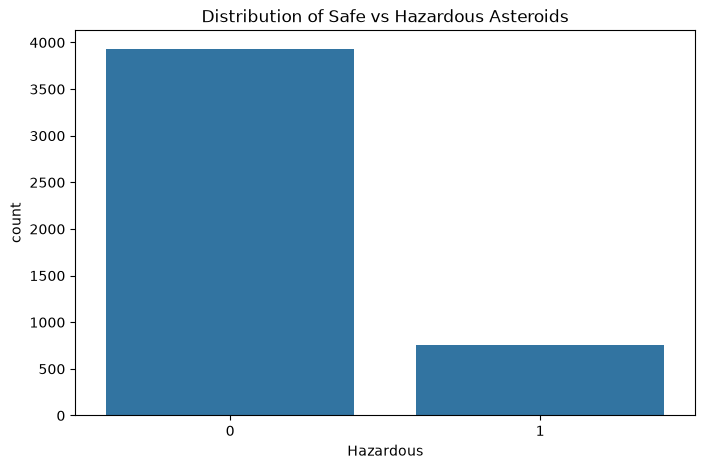

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Hazardous')
plt.title('Distribution of Safe vs Hazardous Asteroids')
plt.show()

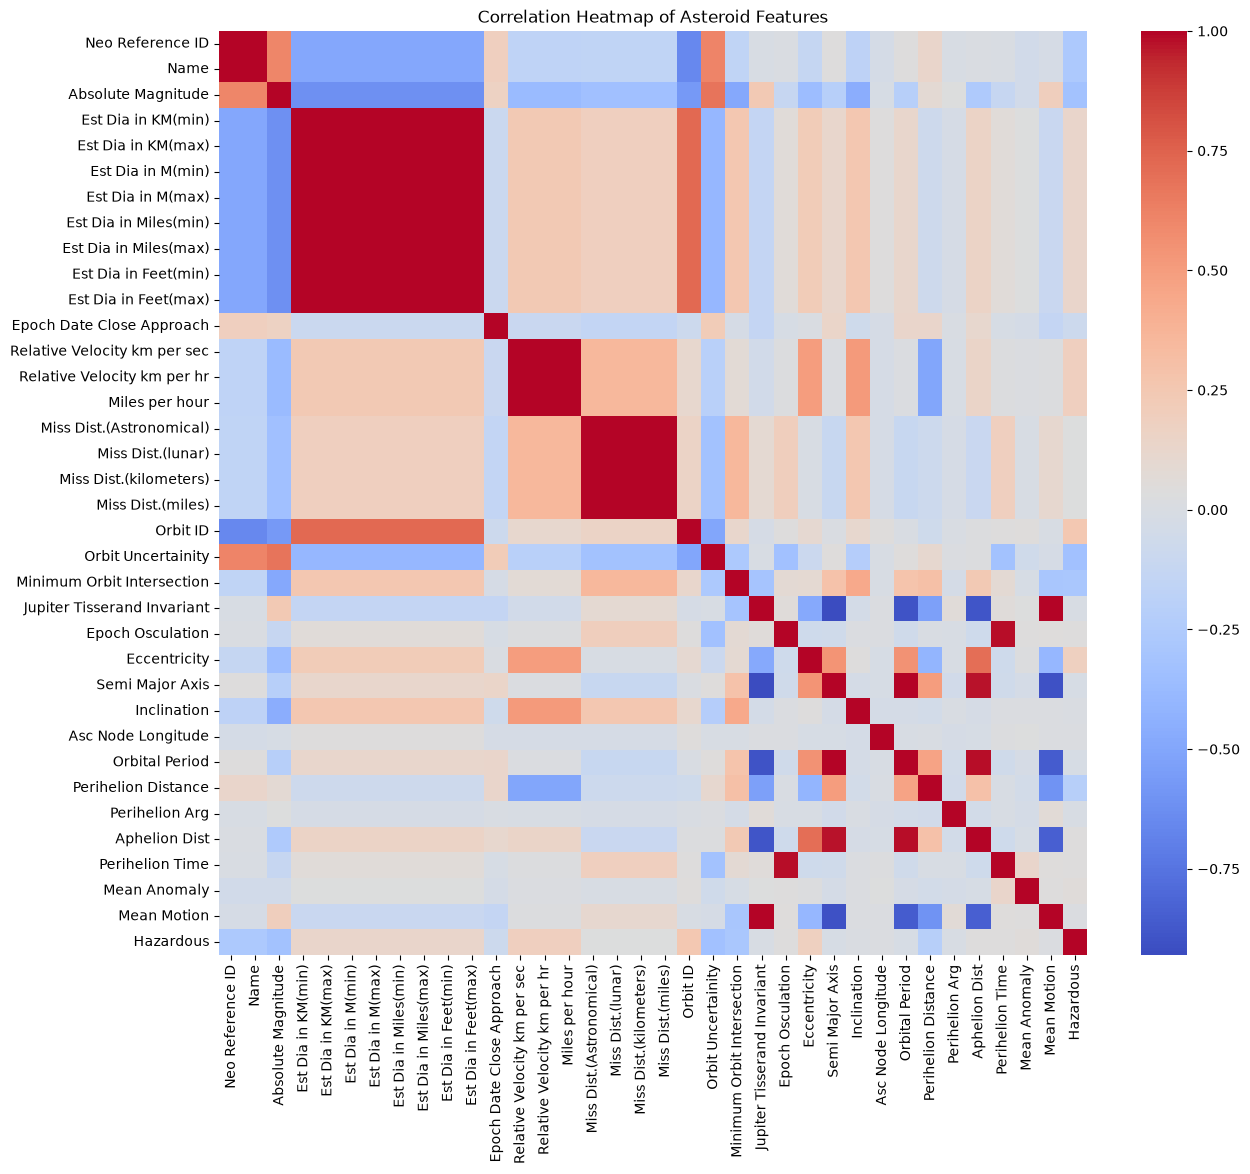

In [7]:
plt.figure(figsize=(14, 12))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap of Asteroid Features')
plt.show()

In [8]:
cols_to_drop=['Neo Reference ID', 'Name', 'Close Approach Date', 'Epoch Date Close Approach','Orbiting Body', 'Orbit Determination Date', 'Equinox', 'Orbit ID','Est Dia in M(min)', 'Est Dia in M(max)', 'Est Dia in Miles(min)',
    'Est Dia in Miles(max)', 'Est Dia in Feet(min)', 'Est Dia in Feet(max)',
    'Relative Velocity km per hour', 'Miles per hour','Miss Dist.(Astronomical)', 'Miss Dist.(Lunispatial)', 'Miss Dist.(Miles)']

df_2=df.drop(columns=[col for col in cols_to_drop if col in df.columns],errors='ignore')
X=df_2.drop(columns=['Hazardous'])
y=df_2['Hazardous']

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (3749, 23), Test size: (938, 23)


In [10]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [11]:
model=LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [12]:
acc=accuracy_score(y_test,y_pred)
prec=precision_score(y_test,y_pred)
rec=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

print("--- STANDARD EVALUATION (50% Threshold) ---")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

--- STANDARD EVALUATION (50% Threshold) ---
Accuracy:  0.9563
Precision: 0.8929
Recall:    0.8278
F1-Score:  0.8591


In [13]:
y_pred_probs=model.predict_proba(X_test)[:,1]

strict_threshold=0.15
y_pred_strict=(y_pred_probs>strict_threshold).astype(int)

strict_acc=accuracy_score(y_test,y_pred_strict)
strict_prec=precision_score(y_test,y_pred_strict)
strict_rec=recall_score(y_test,y_pred_strict)

print("--- SAFETY-FIRST EVALUATION (15% Threshold) ---")
print(f"Accuracy:  {strict_acc:.4f}")
print(f"Precision: {strict_prec:.4f}")
print(f"Recall:    {strict_rec:.4f}")

--- SAFETY-FIRST EVALUATION (15% Threshold) ---
Accuracy:  0.9318
Precision: 0.7062
Recall:    0.9868


In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [15]:
tf.random.set_seed(42)
nn_model=Sequential([
    Dense(16,activation='relu',input_shape=(X_train.shape[1],)),
    Dense(8,activation='relu'),
    Dense(1,activation='sigmoid')
])

nn_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

C:\Users\KS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
history=nn_model.fit(X_train,y_train,validation_split=0.1,epochs=15,batch_size=32,verbose=1)

Epoch 1/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6200 - loss: 0.6305 - val_accuracy: 0.8027 - val_loss: 0.4866
Epoch 2/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8322 - loss: 0.4236 - val_accuracy: 0.8267 - val_loss: 0.3922
Epoch 3/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8414 - loss: 0.3429 - val_accuracy: 0.8240 - val_loss: 0.3455
Epoch 4/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8485 - loss: 0.2955 - val_accuracy: 0.8320 - val_loss: 0.3045
Epoch 5/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8729 - loss: 0.2532 - val_accuracy: 0.8693 - val_loss: 0.2604
Epoch 6/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9055 - loss: 0.2076 - val_accuracy: 0.9120 - val_loss: 0.2057
Epoch 7/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9301 - loss: 0.1650 - val_accuracy: 0.9333 - val_loss: 0.1625
Epoch 8/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9490 - loss: 0.1359 - val_accuracy: 0.

In [17]:
nn_probs=nn_model.predict(X_test).flatten()

nn_pred_50=(nn_probs>0.50).astype(int)
nn_rec_50=recall_score(y_test,nn_pred_50)
nn_acc_50=accuracy_score(y_test,nn_pred_50)

nn_pred_15=(nn_probs>0.15).astype(int)
nn_rec_15=recall_score(y_test,nn_pred_15)
nn_acc_15=accuracy_score(y_test,nn_pred_15)

print("--- NEURAL NETWORK EVALUATION (50% Threshold) ---")
print(f"Accuracy: {nn_acc_50:.4f}")
print(f"Recall:   {nn_rec_50:.4f}")
print("--- NEURAL NETWORK EVALUATION (15% Threshold) ---")
print(f"Accuracy: {nn_acc_15:.4f}")
print(f"Recall:   {nn_rec_15:.4f}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
--- NEURAL NETWORK EVALUATION (50% Threshold) ---
Accuracy: 0.9680
Recall:   0.8742
--- NEURAL NETWORK EVALUATION (15% Threshold) ---
Accuracy: 0.9424
Recall:   0.9801


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

weights=compute_class_weight('balanced',classes=np.unique(y_train),y=y_train)
class_weights={0:weights[0],1:weights[1]}

print(f"Weight for Safe (0):      {class_weights[0]:.2f}")
print(f"Weight for Hazardous (1): {class_weights[1]:.2f}")

nn_model=Sequential([
    Dense(16,activation='relu',input_shape=(X_train.shape[1],)),
    Dense(8,activation='relu'),
    Dense(1,activation='sigmoid')])
nn_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

history_weighted=nn_model.fit(X_train,y_train,validation_split=0.1,epochs=15,batch_size=32,class_weight=class_weights,verbose=0)

nn_probs_weighted=nn_model.predict(X_test).flatten()

nn_pred_15_weighted=(nn_probs_weighted>0.15).astype(int)
nn_rec_15_weighted=recall_score(y_test,nn_pred_15_weighted)
nn_acc_15_weighted=accuracy_score(y_test,nn_pred_15_weighted)

print("--- WEIGHTED NEURAL NETWORK EVALUATION (15% Threshold) ---")
print(f"New Accuracy: {nn_acc_15_weighted:.4f}")
print(f"New Recall:   {nn_rec_15_weighted:.4f}")

Weight for Safe (0):      0.60
Weight for Hazardous (1): 3.10


C:\Users\KS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
--- WEIGHTED NEURAL NETWORK EVALUATION (15% Threshold) ---
New Accuracy: 0.9136
New Recall:   0.9934


In [ ]:
import joblib

joblib.dump(lr,'asteroid_model.pkl')

joblib.dump(scaler, 'asteroid_scaler.pkl')

print("!")